# Problema de negócio
"""
Objetivo: Analisar os fatores que impactam o nível de serviço (NS)
e prever falhas no atendimento.

Contexto:
Projeto baseado em melhoria de processos (Lean Six Sigma),
com foco em redução de falhas operacionais.
"""

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#carregamento dos dados

In [3]:
df = pd.read_csv('/workspaces/previsao-falhas-atendimento-saude/projeto/data/dataset_atendimento.csv')

df.head()

,clientes,guiches,plano_saude,documentos,experiencia_operador,tempo_autorizacao,erros_cadastro,NS,falha
0,111,8,C,nao,media,11,5,70.125,1
1,159,6,E,nao,alta,20,1,52.500,1
2,148,4,C,sim,baixa,7,8,48.000,1
3,123,4,C,nao,media,11,5,53.250,1
4,68,5,E,sim,baixa,13,8,65.400,1


# Estudo dos dados 

In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   clientes              300 non-null    int64  
 1   guiches               300 non-null    int64  
 2   plano_saude           300 non-null    str    
 3   documentos            300 non-null    str    
 4   experiencia_operador  300 non-null    str    
 5   tempo_autorizacao     300 non-null    int64  
 6   erros_cadastro        300 non-null    int64  
 7   NS                    300 non-null    float64
 8   falha                 300 non-null    int64  
dtypes: float64(1), int64(5), str(3)
memory usage: 21.2 KB


,clientes,guiches,tempo_autorizacao,erros_cadastro,NS,falha
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,107.393333,6.576667,13.283333,3.743333,65.321004,0.853333
std,29.049352,1.743825,5.788039,2.589687,9.386345,0.354364
min,60.000000,4.000000,5.000000,0.000000,30.750000,0.000000
25%,81.000000,5.000000,8.000000,2.000000,59.701389,1.000000
50%,107.000000,7.000000,12.500000,3.000000,66.598214,1.000000
75%,132.000000,8.000000,18.000000,5.000000,71.776786,1.000000
max,159.000000,9.000000,26.000000,9.000000,85.250000,1.000000


# Analise exploratoria(EDA)

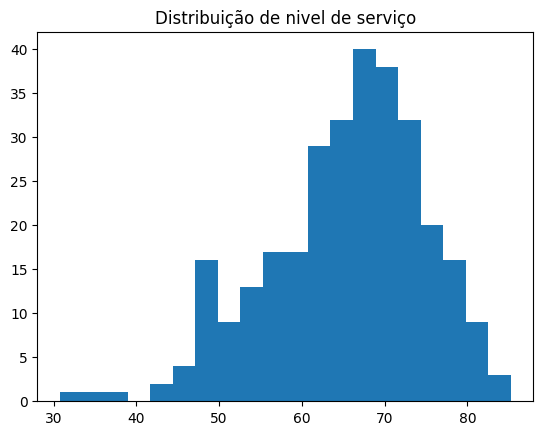

In [5]:
# distribuicao do NS

plt.hist(df['NS'], bins=20)
plt.title('Distribuição de nivel de serviço')
plt.show()

# Relação de Clientes vc NS

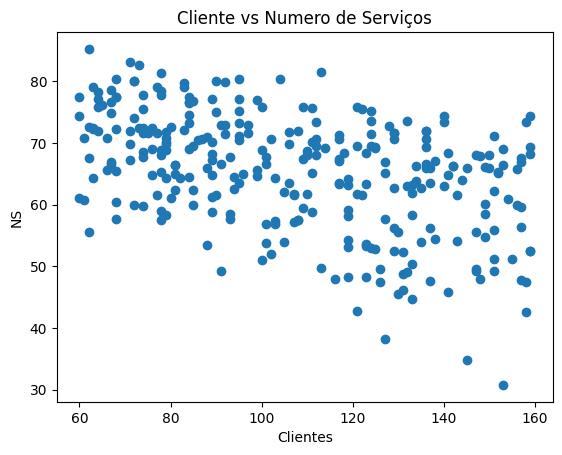

In [6]:
plt.scatter(df['clientes'], df['NS'])
plt.xlabel('Clientes')
plt.ylabel('NS')
plt.title('Cliente vs Numero de Serviços')
plt.show()

# Impacto dos guichês

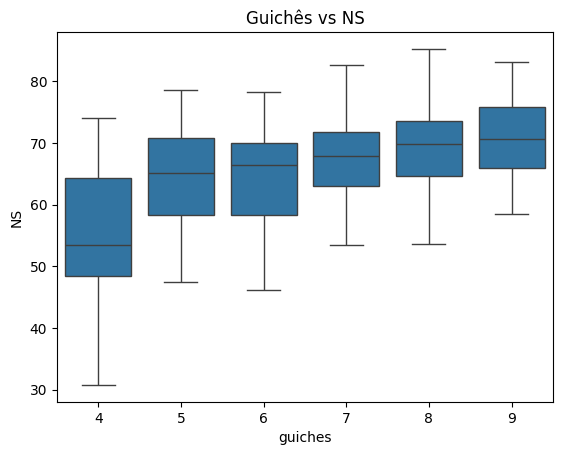

In [7]:
sns.boxplot(x='guiches', y='NS', data=df)
plt.title('Guichês vs NS')
plt.show()

#insight: mais guichês -> melhor atendimento

Plano de Saúde

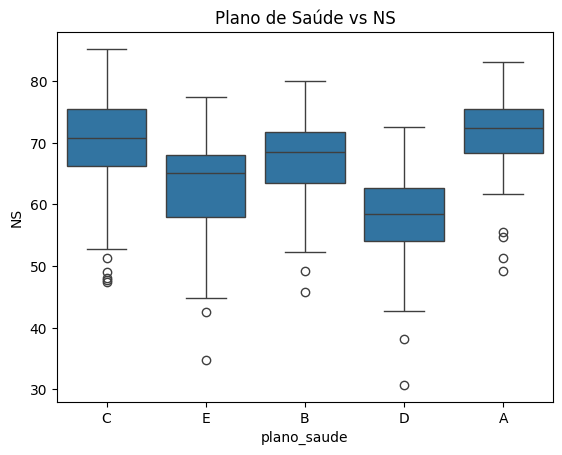

In [8]:
sns.boxplot(x='plano_saude', y='NS', data=df)
plt.title('Plano de Saúde vs NS')
plt.show()

# insight: plano D/E -> Pior desempenho

Documento

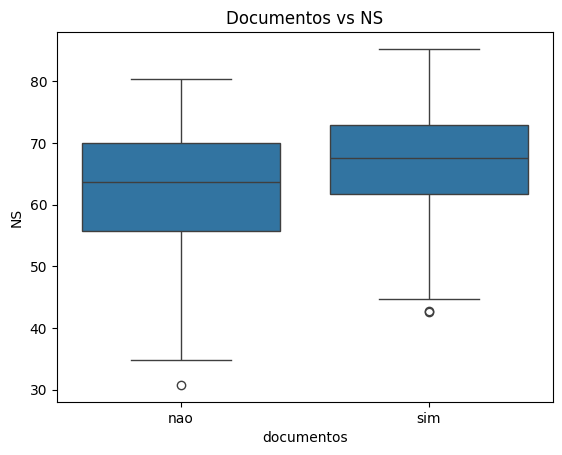

In [9]:
sns.boxplot(x='documentos', y='NS', data=df)
plt.title('Documentos vs NS')
plt.show()

# insight: Sem documento → pior tempo

Experiencia do Operador

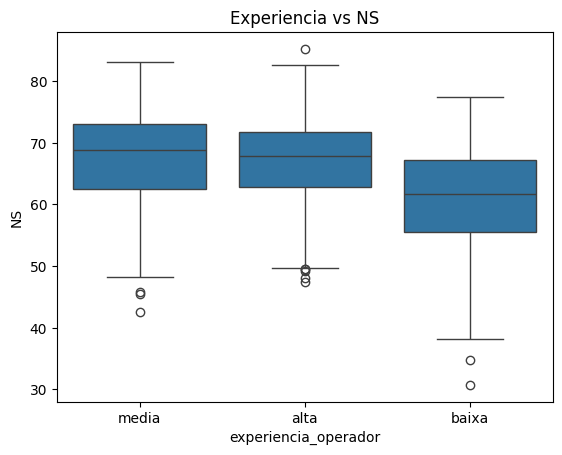

In [10]:
sns.boxplot(x='experiencia_operador', y='NS', data=df)
plt.title('Experiencia vs NS')
plt.show()

Verificando correlação 

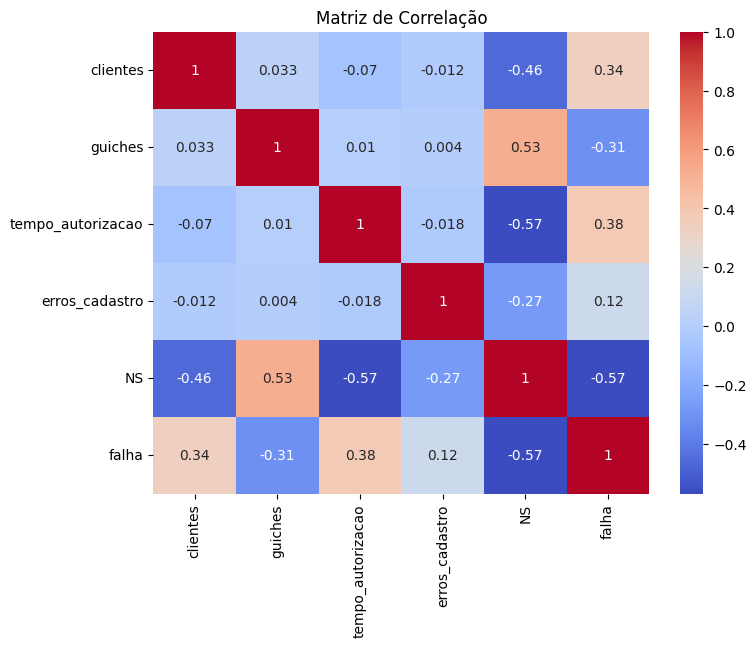

In [11]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title ('Matriz de Correlação')
plt.show()

Analise da leitura do heatmap

Olhando para os dados específicos da acima imagem, podemos notar alguns pontos interessantes:
NS vs. Guiches (0.53): Existe uma correlação positiva moderada. Isso sugere que, geralmente, quanto mais guichês, maior o nível de serviço (NS).
NS vs. Tempo de Autorização (-0.57): Existe uma correlação negativa. Ou seja, quanto maior o tempo de autorização, menor tende a ser o NS (o que faz sentido lógico).
Falha vs. NS (-0.57): Novamente, uma correlação negativa. Quanto mais falhas ocorrem, menor é o NS.
Clientes vs. Erros de Cadastro (-0.012): O valor é quase zero, o que indica que a quantidade de clientes não influencia a quantidade de erros de cadastro.

In [12]:
# Engenharia de Atributos

df['clientes_por_guiche'] = df['clientes'] / df['guiches']

# Preparação para Machine Learning

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['plano_saude'] = le.fit_transform(df['plano_saude'])
df['documentos'] = le.fit_transform(df['documentos'])
df['experiencia_operador'] = le.fit_transform(df['experiencia_operador'])

# -------------------------------------------------------------------------------------------- #

# Analise avançadas de Estatistica (ANOVA, teste t, normalidade)

In [18]:
# teste de normalidade 

from scipy import stats

stat, p = stats.shapiro(df['NS'])

print("Estatistica:", stat)
print("p-valor:", p)

if p > 0.05:
    print("Distribuição normal")
else:
    print("Distribuição não normal")

# interpretação : p > 0.05 (normal) se p < 0.05 (não normal)


Estatistica: 0.9726493471475852
p-valor: 1.7578543307297e-05
Distribuição não normal


In [19]:
from scipy import stats

stat, p = stats.shapiro(df['NS'])

print("Estatística:", stat)
print("p-valor:", p)

if p > 0.05:
    print("Distribuição normal")
else:
    print("Distribuição não normal")

Estatística: 0.9726493471475852
p-valor: 1.7578543307297e-05
Distribuição não normal


In [21]:
# teste T ( documento vc tempo )

com_doc = df[df['documentos'] == 1]['tempo_autorizacao']
sem_doc = df[df['documentos'] == 0]['tempo_autorizacao']

stat, p = stats.ttest_ind(com_doc, sem_doc)

print("p-valor:", p)

if p > 0.05:
    print("nao interfe no tempo ")
else:
    print("interfere no tempo")

# insight esperado : se p < 0.05 falta de documento impacta diretamente no tempo 


p-valor: 4.659935595659724e-13
interfere no tempo


In [ ]:
# teste de ANOVA

import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('tempo_autorizacao ~ C(plano_saude)', data=df).fit()

anova = sm.stats.anova_lm(model, typ=2)

print(anova)


if p > 0.05:
    print("nao impactam o tempo")
else:
    print("impactam o tempo")

# interpretacao p < 0.05 → planos impactam o tempo


                     sum_sq     df           F         PR(>F)
C(plano_saude)  8346.268776    4.0  368.442282  2.292569e-113
Residual        1670.647891  295.0         NaN            NaN
impactam o tempo


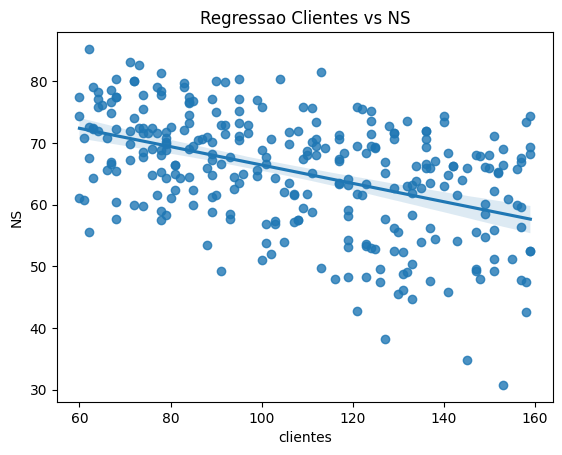

In [30]:
# regressap linear (cliente vs guiches)

import seaborn as sns

sns.regplot(x = 'clientes', y = 'NS', data=df)

plt.title('Regressao Clientes vs NS')
plt.show()